# 🧮 Handwritten Math Expression Solver
> **Deep Learning Project #1** — Recognize and solve handwritten multi-digit math expressions

## 📋 Project Overview
This project builds an end-to-end pipeline that:
1. **Detects** individual symbols (digits 0–9 and operators +, −, ×, ÷) from a handwritten image
2. **Classifies** each symbol using a CNN trained on MNIST + CROHME datasets
3. **Parses** the detected sequence into a valid math expression
4. **Evaluates** and returns the result

## 🗂️ Pipeline
```
Image → Preprocessing → Segmentation → CNN Classifier → Expression Parser → Result
```

## 📦 Datasets Used
| Dataset | Purpose | Classes |
|---|---|---|
| MNIST | Handwritten digits | 0–9 |
| Kaggle Handwritten Math Symbols | Operators | +, −, ×, ÷, =, (, ) |

---

## ⚙️ Step 1: Install & Import Dependencies

In [ ]:
# Install required libraries
!pip install -q kaggle opencv-python-headless matplotlib seaborn scikit-learn

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image, ImageDraw, ImageFont
import random
import math

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

TensorFlow version: 2.20.0
GPU available: True


## 📊 Step 2: Load & Prepare Datasets

### 2a. Load MNIST (Digits 0–9)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST Train: (60000, 28, 28), Test: (10000, 28, 28)


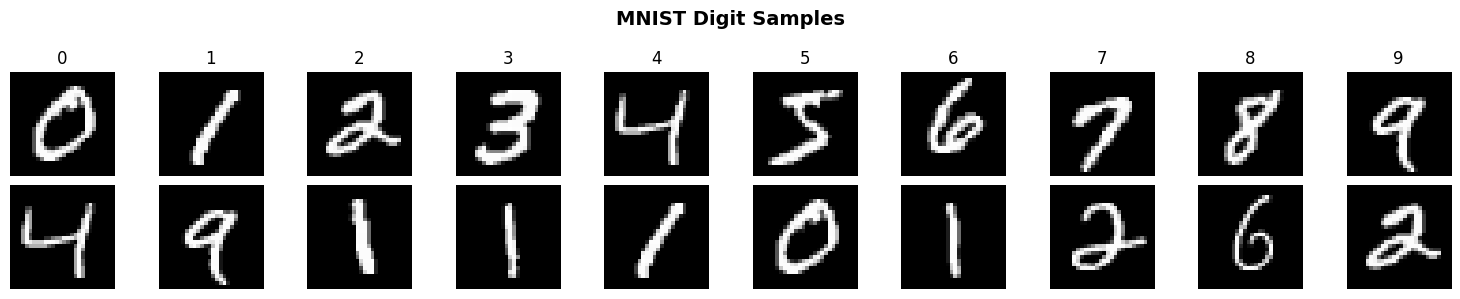

In [ ]:
# Load MNIST
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()

print(f"MNIST Train: {x_train_mnist.shape}, Test: {x_test_mnist.shape}")

# Visualize some samples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    idx = np.where(y_train_mnist == i)[0][0]
    axes[0, i].imshow(x_train_mnist[idx], cmap='gray')
    axes[0, i].set_title(str(i))
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_mnist[idx + 1], cmap='gray')
    axes[1, i].axis('off')
plt.suptitle('MNIST Digit Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2b. Load Operator Symbols from Kaggle Dataset

We use the [Kaggle Handwritten Math Symbols](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols)
dataset for real handwritten +, −, ×, ÷ samples — far more realistic than synthetic generation.

In [ ]:
import kagglehub
import glob

# Download the dataset (cached after first run)
dataset_path = kagglehub.dataset_download("sagyamthapa/handwritten-math-symbols")
print("Dataset downloaded to:", dataset_path)

# Inspect folder structure to find the actual symbol folder names
all_dirs = sorted(glob.glob(os.path.join(dataset_path, '**'), recursive=True))
symbol_dirs = [d for d in all_dirs if os.path.isdir(d) and len(os.listdir(d)) > 0
               and any(f.lower().endswith(('.png','.jpg','.jpeg')) for f in os.listdir(d))]
print("Found symbol folders:")
for d in symbol_dirs:
    print(f"  {os.path.relpath(d, dataset_path):<20} -> {len(os.listdir(d))} images")

# Map dataset folder names -> our class IDs (10-13)
# Classes 10-15: +, -, x, /, ., =
operator_map = {
    10: '+',
    11: '-',
    12: 'x',
    13: '/',
    14: '.',
    15: '=',
}

alias_map = {
    '+': ['add'],
    '-': ['sub'],
    'x': ['mul'],
    '/': ['div'],
    '.': ['dec'],
    '=': ['eq'],
}



Using Colab cache for faster access to the 'handwritten-math-symbols' dataset.
Dataset downloaded to: /kaggle/input/handwritten-math-symbols
Found symbol folders:
  dataset/0            -> 595 images
  dataset/1            -> 562 images
  dataset/2            -> 433 images
  dataset/3            -> 541 images
  dataset/4            -> 526 images
  dataset/5            -> 433 images
  dataset/6            -> 581 images
  dataset/7            -> 533 images
  dataset/8            -> 554 images
  dataset/9            -> 547 images
  dataset/add          -> 596 images
  dataset/dec          -> 624 images
  dataset/div          -> 618 images
  dataset/eq           -> 634 images
  dataset/mul          -> 577 images
  dataset/sub          -> 655 images
  dataset/x            -> 452 images
  dataset/y            -> 399 images
  dataset/z            -> 212 images



Loading operator images from dataset...
  Class 10 ('+') <- 'add': 596 images loaded
  Class 11 ('-') <- 'sub': 655 images loaded
  Class 12 ('x') <- 'mul': 577 images loaded
  Class 13 ('/') <- 'div': 618 images loaded
  Class 14 ('.') <- 'dec': 624 images loaded
  Class 15 ('=') <- 'eq': 634 images loaded


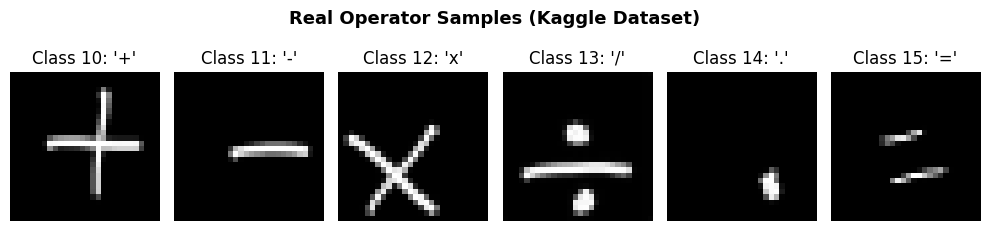


Operator dataset: (3704, 28, 28)


In [ ]:
def find_folder_for_symbol(symbol):
    """Match a dataset folder to our target symbol using aliases."""
    candidates = alias_map[symbol]
    for d in symbol_dirs:
        folder_name = os.path.basename(d.rstrip('/')).lower()
        if folder_name in [c.lower() for c in candidates]:
            return d
    return None

def load_operator_images(folder, img_size=28, max_samples=6000):
    """Load, grayscale, threshold (MNIST-style white-on-black), resize."""
    files = glob.glob(os.path.join(folder, '*'))
    files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(files)
    files = files[:max_samples]

    images = []
    for f in files:
        img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
        # Ensure MNIST-style: white strokes on black background
        if img.mean() > 127:
            img = 255 - img
        images.append(img)
    return np.array(images)

print("\nLoading operator images from dataset...")
operator_images = []
operator_labels = []

for class_id, symbol in operator_map.items():
    folder = find_folder_for_symbol(symbol)
    if folder is None:
        raise ValueError(f"Could not find a dataset folder for symbol '{symbol}'. "
                          f"Available folders: {[os.path.basename(d) for d in symbol_dirs]}")
    imgs = load_operator_images(folder)
    operator_images.append(imgs)
    operator_labels.extend([class_id] * len(imgs))
    print(f"  Class {class_id} ('{symbol}') <- '{os.path.basename(folder)}': {len(imgs)} images loaded")

operator_images = np.concatenate(operator_images, axis=0)
operator_labels = np.array(operator_labels)

# Show samples
fig, axes = plt.subplots(1, 6, figsize=(10, 2.5))
for i, (class_id, sym) in enumerate(operator_map.items()):
    idx = np.where(operator_labels == class_id)[0][0]
    axes[i].imshow(operator_images[idx], cmap='gray')
    axes[i].set_title(f"Class {class_id}: '{sym}'")
    axes[i].axis('off')
plt.suptitle('Real Operator Samples (Kaggle Dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOperator dataset: {operator_images.shape}")

### 2c. Combine & Preprocess All Data

Total classes: 16 — ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', 'x', '/', '.', '=']
Combined dataset: 73,704 images

Train : 58,963
Val   : 7,370
Test  : 7,371


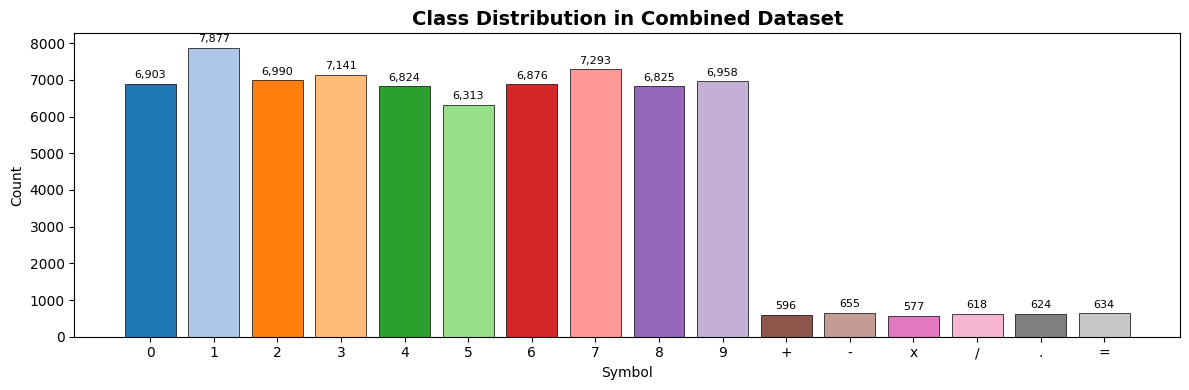

In [ ]:
# Class label mapping
CLASS_NAMES = ['0','1','2','3','4','5','6','7','8','9', '+', '-', 'x', '/', '.', '=']
NUM_CLASSES = len(CLASS_NAMES)  # 16
print(f"Total classes: {NUM_CLASSES} — {CLASS_NAMES}")

# ── Combine MNIST (all) + operators ──────────────────────────────────────────
all_images = np.concatenate([
    x_train_mnist,       # 60,000 digit images
    x_test_mnist,        # 10,000 digit images
    operator_images      # 24,000 operator images
], axis=0)

all_labels = np.concatenate([
    y_train_mnist,
    y_test_mnist,
    operator_labels
], axis=0)

print(f"Combined dataset: {all_images.shape[0]:,} images")

# ── Normalize & Reshape ───────────────────────────────────────────────────────
X = all_images.astype('float32') / 255.0
X = X[..., np.newaxis]   # → (N, 28, 28, 1)
y = to_categorical(all_labels, NUM_CLASSES)

# ── Train / Validation / Test Split ──────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=all_labels)
X_val, X_test, y_val, y_test   = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nTrain : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

# Class distribution plot
label_counts = pd.Series(all_labels).value_counts().sort_index()
plt.figure(figsize=(12, 4))
bars = plt.bar(CLASS_NAMES, label_counts.values, color=plt.cm.tab20.colors[:NUM_CLASSES], edgecolor='black', linewidth=0.5)
plt.title('Class Distribution in Combined Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Symbol')
plt.ylabel('Count')
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{count:,}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 🏗️ Step 3: Build the CNN Model

In [ ]:
def build_cnn(num_classes=14, input_shape=(28, 28, 1)):
    """
    A compact but powerful CNN for symbol classification.
    Architecture: 3 Conv blocks → GlobalAvgPool → Dense head
    """
    inputs = keras.Input(shape=input_shape)

    # ── Block 1 ──────────────────────────────────────────
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 2 ──────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3 ──────────────────────────────────────────
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    # ── Head ──────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='MathSymbolCNN')

model = build_cnn(NUM_CLASSES)
model.summary()

# Visualize architecture
print(f"\nTotal parameters: {model.count_params():,}")

Model: "MathSymbolCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 177,264 (692.44 KB)

 Trainable params: 176,624 (689.94 KB)

 Non-trainable params: 640 (2.50 KB)


Total parameters: 177,264


## 🏋️ Step 4: Train the Model

In [ ]:
# ── Data Augmentation ─────────────────────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=5,
    fill_mode='nearest'
)

# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

BATCH_SIZE = 256
EPOCHS     = 30

# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.7774 - loss: 0.7242 - val_accuracy: 0.0943 - val_loss: 12.7297 - learning_rate: 0.0010
Epoch 2/30
  1/230 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9453 - loss: 0.1685

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9453 - loss: 0.1685 - val_accuracy: 0.0943 - val_loss: 12.1738 - learning_rate: 0.0010
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.9519 - loss: 0.1636 - val_accuracy: 0.2156 - val_loss: 6.5766 - learning_rate: 0.0010
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0761 - val_accuracy: 0.2142 - val_loss: 6.7166 - learning_rate: 0.0010
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9686 - loss: 0.1081 - val_accuracy: 0.9596 - val_loss: 0.1336 - learning_rate: 0.0010
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.1087 - val_accuracy: 0.9564 - val_loss: 0.1433 - learning_rate: 0.0010
Epoch 7/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.9751 - loss: 0.0865 - val_accuracy: 0.9794 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 8/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0498 - val_

## 📈 Step 5: Visualize Training Results

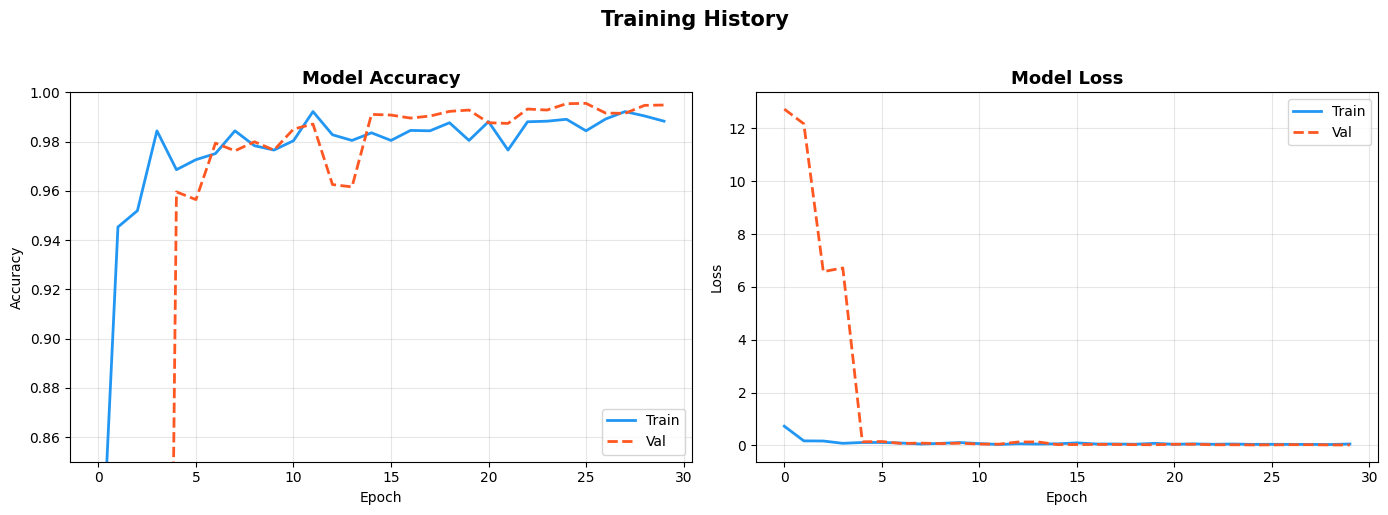

In [ ]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train', color='#2196F3', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   color='#FF5722', linewidth=2, linestyle='--')
    ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_ylim([0.85, 1.0])

    # Loss
    ax2.plot(history.history['loss'],     label='Train', color='#2196F3', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val',   color='#FF5722', linewidth=2, linestyle='--')
    ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Training History', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_training_history(history)

## 🧪 Step 6: Evaluate on Test Set


  Test Accuracy : 99.35%
  Test Loss     : 0.0206

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       690
           1       1.00      0.99      1.00       778
           2       1.00      0.99      0.99       752
           3       1.00      1.00      1.00       706
           4       0.99      0.99      0.99       673
           5       0.99      0.99      0.99       620
           6       0.99      0.99      0.99       711
           7       0.99      0.99      0.99       718
           8       0.99      0.99      0.99       670
           9       0.98      1.00      0.99       703
           +       1.00      0.98      0.99        61
           -       1.00      1.00      1.00        61
           x       1.00      1.00      1.00        58
           /       0.98      1.00      0.99        61
           .       1.00      1.00      1.00        51
           =       1.00      0.98      0.99        58

    a

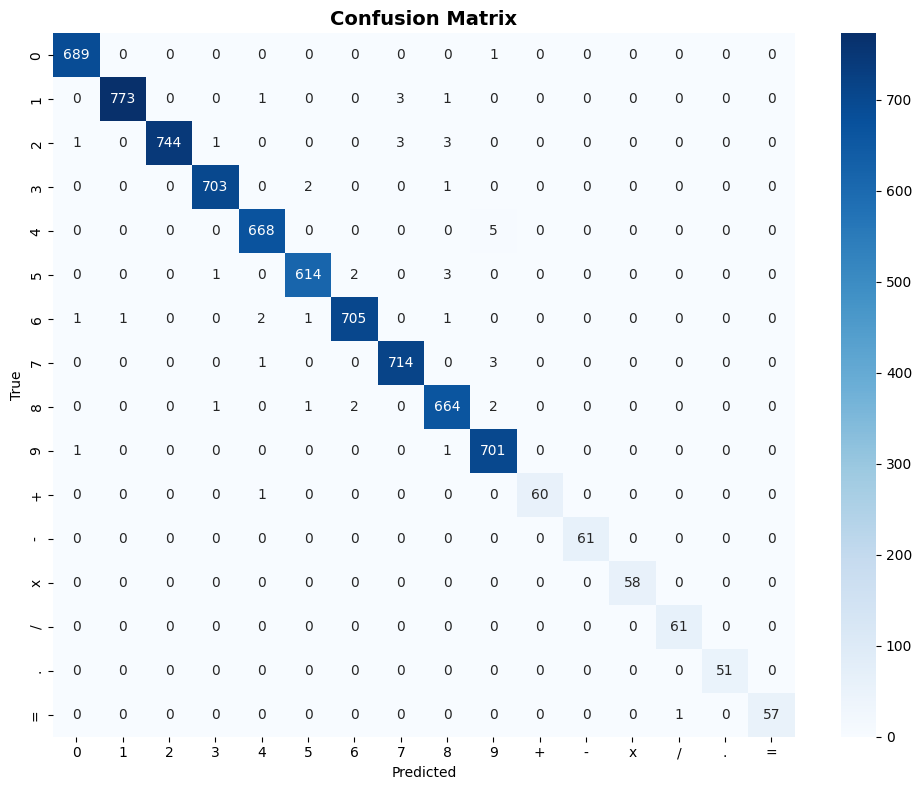

In [ ]:
# ── Test accuracy ─────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'='*40}")

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test, axis=1)

# ── Classification Report ─────────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 🔣 Step 7: Expression Parser & Evaluator

In [ ]:
class MathExpressionSolver:
    OPERATOR_MAP = {'+': '+', '-': '-', 'x': '*', '/': '/', '.': '.', '=': '='}

    def parse(self, symbols: list) -> str:
      tokens = []
      i = 0
      while i < len(symbols):
          sym = symbols[i]
          if sym.isdigit() or sym == '.':
              num = sym
              while i + 1 < len(symbols) and (symbols[i+1].isdigit() or symbols[i+1] == '.'):
                  i += 1
                  num += symbols[i]
              tokens.append(num)
          elif sym in self.OPERATOR_MAP:
              mapped = self.OPERATOR_MAP[sym]
              # Skip duplicate consecutive '=' (split equals sign)
              if mapped == '=' and tokens and tokens[-1] == '=':
                  i += 1
                  continue
              tokens.append(mapped)
          i += 1
      return ' '.join(tokens)

    def evaluate(self, expression: str):
        try:
            allowed = set('0123456789 +-*/.()=')
            if not all(c in allowed for c in expression):
                return None, "Invalid characters in expression"

            if '=' in expression:
                lhs = expression.split('=')[0].strip()
                if not lhs:
                    return None, "Empty expression before '='"
                result = eval(lhs)
                return result, None

            result = eval(expression)
            return result, None
        except ZeroDivisionError:
            return None, "Division by zero"
        except Exception as e:
            return None, str(e)

    def solve(self, symbols: list):
        expr = self.parse(symbols)
        result, error = self.evaluate(expr)
        return expr, result, error

## 🖼️ Step 8: Image Segmentation & Full Pipeline

In [ ]:
class SymbolSegmenter:
    """
    Segments a math expression image into individual symbol crops
    using connected component analysis.
    """

    def preprocess(self, img_array: np.ndarray) -> np.ndarray:
        """Convert to grayscale, threshold, clean noise."""
        if len(img_array.shape) == 3:
            gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
        else:
            gray = img_array.copy()

        # Invert if background is white (MNIST style: black bg, white strokes)
        if gray.mean() > 127:
            gray = 255 - gray

        # Otsu threshold + morphological cleanup
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        return binary

    def segment(self, binary: np.ndarray, padding=4):
      # Dilate horizontally to merge close strokes (like '=' lines) into one component
      kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))  # tall thin kernel: merges vertically-stacked nearby strokes
      dilated = cv2.dilate(binary, kernel, iterations=1)

      n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(dilated)

      boxes = []
      for i in range(1, n_labels):
          x, y, w, h, area = stats[i]
          if area < 30:
              continue
          boxes.append((x, y, w, h))

      boxes.sort(key=lambda b: b[0])
      return boxes

    def extract_crops(self, binary: np.ndarray, boxes, size=28, padding=4):
        """Crop, pad, and resize each bounding box to 28×28."""
        crops = []
        H, W = binary.shape
        for (x, y, w, h) in boxes:
            x1 = max(0, x - padding)
            y1 = max(0, y - padding)
            x2 = min(W, x + w + padding)
            y2 = min(H, y + h + padding)
            crop = binary[y1:y2, x1:x2]
            crop = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)
            crops.append(crop.astype('float32') / 255.0)
        return crops


class HandwrittenMathSolver:
    """End-to-end pipeline: image → answer."""

    def __init__(self, model, class_names):
        self.model      = model
        self.class_names = class_names
        self.segmenter  = SymbolSegmenter()
        self.solver     = MathExpressionSolver()

    def predict_symbols(self, crops):
        """Run CNN on all crops and return class labels."""
        if not crops:
            return []
        batch = np.array(crops)[..., np.newaxis]   # (N, 28, 28, 1)
        probs = self.model.predict(batch, verbose=0)
        idxs  = np.argmax(probs, axis=1)
        return [self.class_names[i] for i in idxs], probs

    def solve_image(self, img_array: np.ndarray, visualize=True):
        """Full pipeline with optional visualization."""
        # 1. Preprocess
        binary = self.segmenter.preprocess(img_array)

        # 2. Segment
        boxes = self.segmenter.segment(binary)
        if not boxes:
            print("No symbols detected.")
            return [], "", None

        # 3. Extract crops
        crops = self.segmenter.extract_crops(binary, boxes)

        # 4. Classify
        symbols, probs = self.predict_symbols(crops)

        # 5. Solve
        expression, result, error = self.solver.solve(symbols)

        # 6. Visualize
        if visualize:
            self._visualize(img_array, binary, boxes, crops, symbols, probs, expression, result, error)

        return symbols, expression, result

    def _visualize(self, orig, binary, boxes, crops, symbols, probs, expression, result, error):
        n = len(boxes)
        fig = plt.figure(figsize=(max(14, n*2), 8))
        gs = fig.add_gridspec(2, max(n, 1) + 2, hspace=0.4, wspace=0.3)

        # Original image
        ax_orig = fig.add_subplot(gs[0, :2])
        ax_orig.imshow(orig if len(orig.shape) == 3 else orig, cmap='gray' if len(orig.shape) == 2 else None)
        ax_orig.set_title('Input Image', fontweight='bold')
        ax_orig.axis('off')
        for (x, y, w, h) in boxes:
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
            ax_orig.add_patch(rect)

        # Binary image
        ax_bin = fig.add_subplot(gs[1, :2])
        ax_bin.imshow(binary, cmap='gray')
        ax_bin.set_title('After Preprocessing', fontweight='bold')
        ax_bin.axis('off')

        # Individual crops with predictions
        for i, (crop, sym, prob) in enumerate(zip(crops, symbols, probs)):
            ax = fig.add_subplot(gs[0, i + 2])
            ax.imshow(crop, cmap='gray')
            conf = np.max(prob) * 100
            ax.set_title(f"'{sym}'\n{conf:.0f}%", fontsize=9, color='green' if conf > 80 else 'orange')
            ax.axis('off')

        # Result box
        result_text = f"{expression} = {result:.6g}" if result is not None else f"ERROR: {error}"
        color = '#e8f5e9' if result is not None else '#ffebee'
        fig.text(0.5, 0.02, f"🧮  {result_text}", ha='center', va='bottom',
                 fontsize=16, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='gray'))

        plt.suptitle('Handwritten Math Solver — Full Pipeline', fontsize=14, fontweight='bold')
        plt.show()

print("Pipeline classes defined ✅")

Pipeline classes defined ✅


## 🧪 Step 9: Test with Synthetic Expression Images


  Testing: 12+34


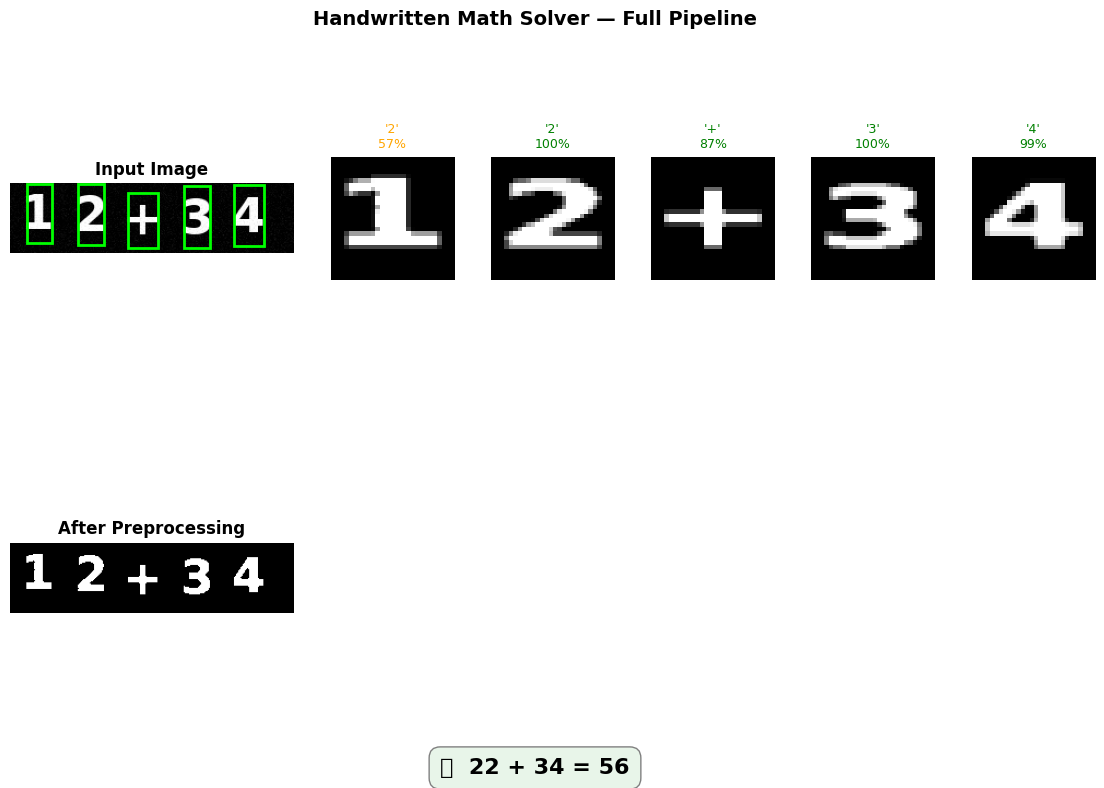


  Testing: 9x8


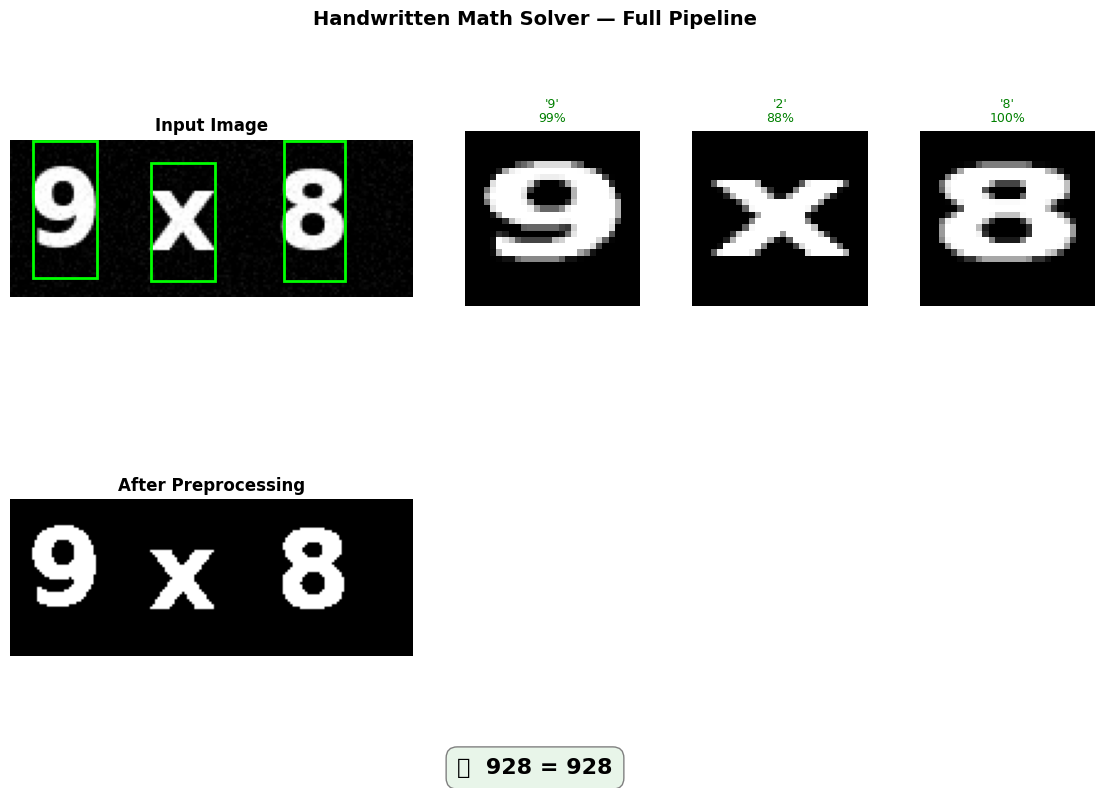


  Testing: 100/4


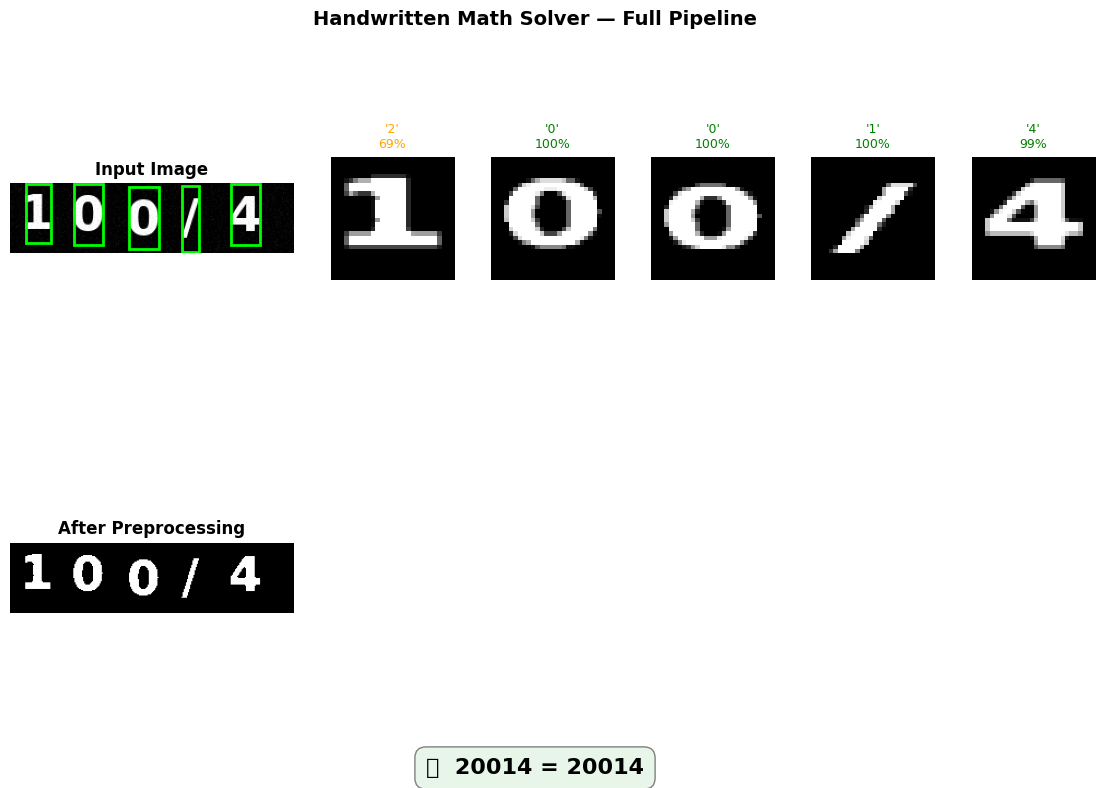


  Testing: 55-23


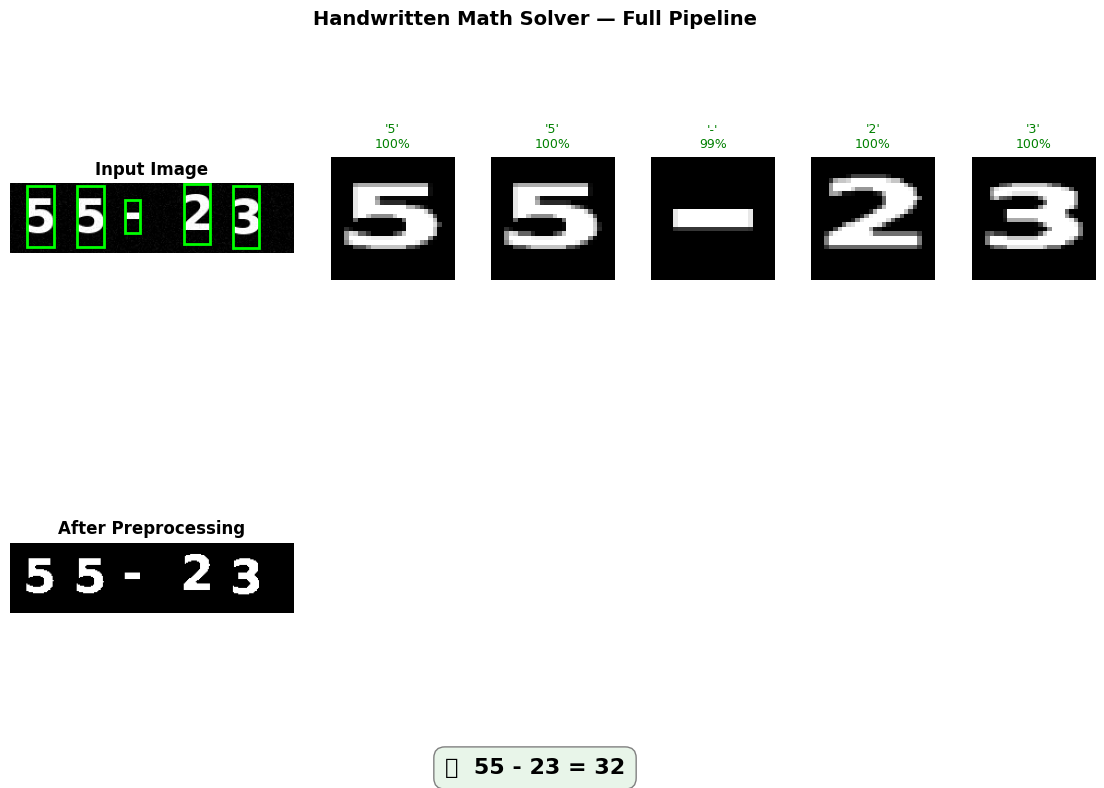


  Testing: 123+456


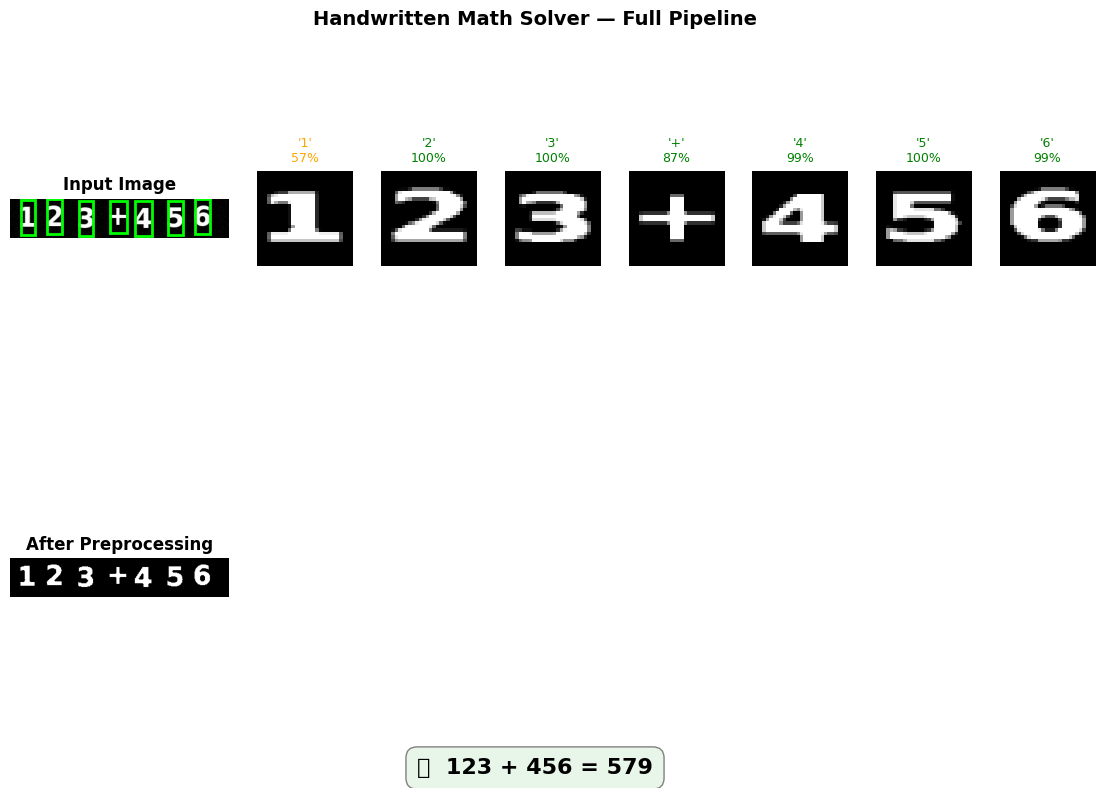

In [ ]:
def get_font(size=44):
    paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]
    for p in paths:
        if os.path.exists(p):
            return ImageFont.truetype(p, size)
    # Last resort: Pillow's scalable default (Pillow >= 10)
    try:
        return ImageFont.load_default(size=size)
    except TypeError:
        raise RuntimeError("No usable font found — run: !apt-get install -y fonts-dejavu-core")

FONT = get_font(44)

def make_expression_image(expression_str, img_height=64, symbol_width=48):
    chars = list(expression_str.replace(' ', ''))
    W = symbol_width * len(chars) + 20
    img = Image.new('L', (W, img_height), color=0)
    draw = ImageDraw.Draw(img)

    for i, ch in enumerate(chars):
        x = 10 + i * symbol_width + random.randint(-3, 3)
        y = 4 + random.randint(-3, 3)
        draw.text((x, y), ch, fill=255, font=FONT)

    arr = np.array(img)
    noise = np.random.normal(0, 8, arr.shape).astype(np.int16)
    arr = np.clip(arr.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return arr

# Instantiate the full solver
math_solver = HandwrittenMathSolver(model, CLASS_NAMES)

# Test expressions
test_expressions = [
    "12+34",
    "9x8",
    "100/4",
    "55-23",
    "123+456",
]

for expr_str in test_expressions:
    print(f"\n{'='*60}")
    print(f"  Testing: {expr_str}")
    print(f"{'='*60}")
    img = make_expression_image(expr_str)
    symbols, expression, result = math_solver.solve_image(img, visualize=True)

## 📸 Step 10: Try Your Own Image!

Upload a real photo of a handwritten math expression.

In [ ]:
!apt-get install -y fonts-dejavu-core -q

Reading package lists...
Building dependency tree...
Reading state information...
fonts-dejavu-core is already the newest version (2.37-2build1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


📂 Upload an image of a handwritten math expression...


Saving {AB4EF542-7823-4A96-B476-F6F5D6E1CCDC}.png to {AB4EF542-7823-4A96-B476-F6F5D6E1CCDC} (4).png

Processing: {AB4EF542-7823-4A96-B476-F6F5D6E1CCDC} (4).png


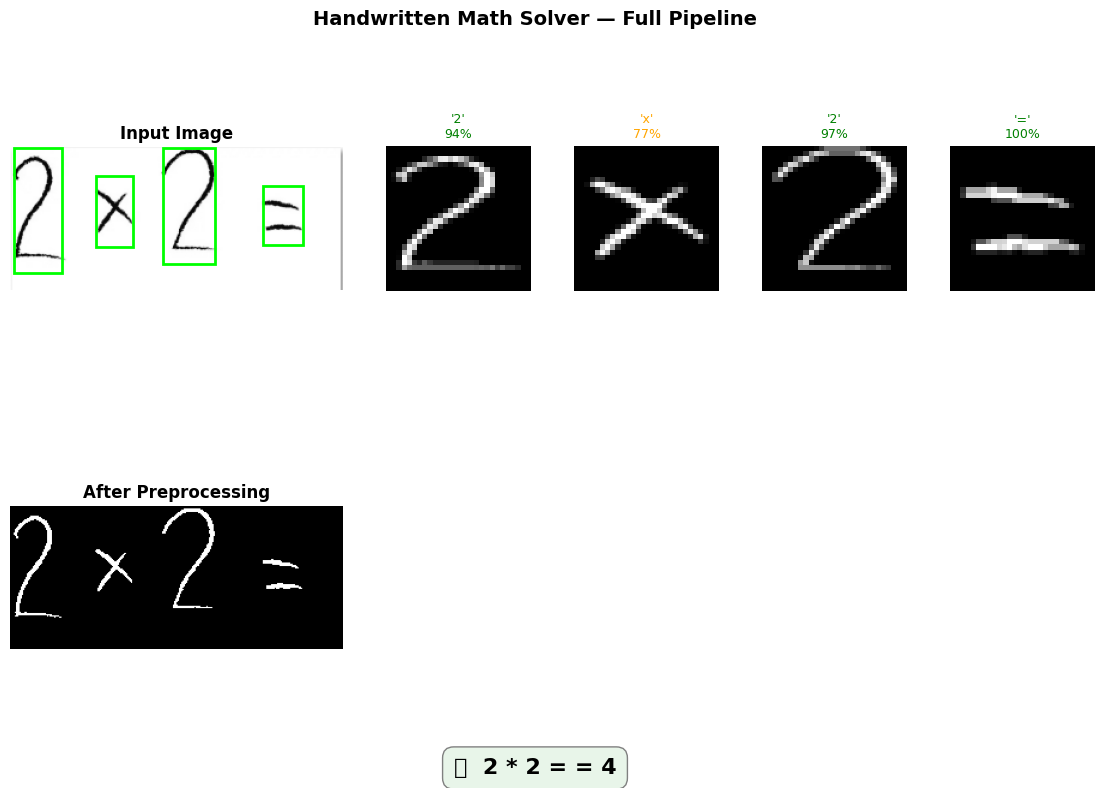


✅ Final Answer: 2 * 2 = = 4


In [ ]:
from google.colab import files
import io

print("📂 Upload an image of a handwritten math expression...")
uploaded = files.upload()

for filename, data in uploaded.items():
    print(f"\nProcessing: {filename}")
    img_array = np.array(Image.open(io.BytesIO(data)).convert('L'))
    symbols, expression, result = math_solver.solve_image(img_array, visualize=True)
    if result is not None:
        print(f"\n✅ Final Answer: {expression} = {result}")
    else:
        print("\n❌ Could not solve the expression. Try a clearer image.")

## 💾 Step 11: Save the Model

In [ ]:
# Save full model
model.save('handwritten_math_solver.keras')
print("Model saved as 'handwritten_math_solver.keras'")

# Also save as TFLite for mobile deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('math_solver.tflite', 'wb') as f:
    f.write(tflite_model)
print("TFLite model saved as 'math_solver.tflite'")
print(f"TFLite model size: {len(tflite_model) / 1024:.1f} KB")

# Download both files
files.download('handwritten_math_solver.keras')
files.download('math_solver.tflite')

Model saved as 'handwritten_math_solver.keras'
Saved artifact at '/tmp/tmp60daht7y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  132139716965200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139716967312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139563106960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139716967120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139716966928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139563106384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139716968272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139563107920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139563108880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132139563109072: TensorSpec(shape=(), 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 🚀 Next Steps & Improvements

| Improvement | How |
|---|---|
| **Real operator images** | Download [Kaggle Handwritten Math Symbols](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols) and replace synthetic data |
| **Parentheses support** | Add `(` and `)` as classes 14 & 15, handle grouping in parser |
| **CROHME dataset** | Use the Competition on Recognition of Online Handwritten Mathematical Expressions dataset |
| **Transfer learning** | Fine-tune MobileNetV2 for better accuracy with fewer samples |
| **Web demo** | Deploy with Gradio: `import gradio as gr` |
| **Exponent support** | Detect superscript position for powers (e.g. 2³) |
| **Sequence model** | Replace segmentation+CNN with a CRNN (CNN + LSTM) for end-to-end recognition |

## 📚 Resources
- [CROHME Dataset](https://www.isical.ac.in/~crohme/)
- [TensorFlow Image Classification Guide](https://www.tensorflow.org/tutorials/images/classification)
- [OpenCV Connected Components](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html)
- [Kaggle Math Symbols Dataset](https://www.kaggle.com/datasets/sagyamthapa/handwritten-math-symbols)

---
*Project 1 of 12 — Deep Learning Portfolio*